Caso queira ver o modelo pelo Google colab aqui está o link: 
https://colab.research.google.com/drive/1ws-04aP0Y6vV66HCadMnZg3KVXV1P0aj?usp=sharing

## BUSINESS UNDERSTANDING

Construir um modelo para classificar consumo de água.

#Importando dados


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("../data/irrigation_prediction.csv")

### EDA - Análise Exploratória de Dados

In [3]:
df.head(20)

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,Clay,6.14,36.48,0.42,2.17,21.90,31.19,1167.70,4.01,1.97,Wheat,Vegetative,Rabi,Rainfed,Reservoir,4.73,Yes,1.98,South,Low
1,Silt,6.41,50.56,0.38,0.23,36.50,26.01,831.28,10.72,16.82,Maize,Flowering,Zaid,Canal,Groundwater,12.22,Yes,33.56,Central,Medium
2,Sandy,7.71,40.07,1.09,2.18,41.83,76.41,1844.45,7.75,19.03,Cotton,Harvest,Rabi,Drip,Reservoir,5.52,Yes,34.62,South,Low
3,Clay,5.96,12.75,1.56,0.40,37.22,43.32,306.26,8.90,11.44,Wheat,Sowing,Kharif,Canal,Reservoir,1.43,Yes,84.03,North,Medium
4,Clay,7.76,18.58,0.95,2.52,22.38,86.44,1875.63,10.39,11.26,Cotton,Sowing,Zaid,Canal,River,2.52,No,60.86,South,Medium
5,Silt,5.10,20.50,0.37,1.43,33.34,62.51,402.92,7.03,13.55,Rice,Sowing,Zaid,Sprinkler,Groundwater,7.56,Yes,7.33,East,Medium
6,Sandy,7.44,22.70,0.59,2.95,28.02,58.50,764.95,7.08,7.38,Rice,Flowering,Kharif,Sprinkler,Reservoir,2.18,No,51.47,West,Medium
7,Sandy,7.68,40.23,0.62,3.30,35.60,79.10,833.33,5.17,3.73,Wheat,Vegetative,Zaid,Rainfed,Reservoir,12.54,Yes,118.96,West,Low
8,Clay,5.42,36.73,0.74,1.52,16.59,76.88,2476.03,10.34,1.80,Maize,Flowering,Kharif,Sprinkler,Rainwater,13.75,Yes,107.25,Central,Low
9,Loamy,6.26,19.58,0.36,1.67,31.14,74.30,1474.55,8.53,17.68,Rice,Vegetative,Rabi,Rainfed,Reservoir,1.27,Yes,97.92,Central,Medium


In [4]:
df.columns.tolist()

['Soil_Type',
 'Soil_pH',
 'Soil_Moisture',
 'Organic_Carbon',
 'Electrical_Conductivity',
 'Temperature_C',
 'Humidity',
 'Rainfall_mm',
 'Sunlight_Hours',
 'Wind_Speed_kmh',
 'Crop_Type',
 'Crop_Growth_Stage',
 'Season',
 'Irrigation_Type',
 'Water_Source',
 'Field_Area_hectare',
 'Mulching_Used',
 'Previous_Irrigation_mm',
 'Region',
 'Irrigation_Need']

In [5]:
df.dtypes

Soil_Type                   object
Soil_pH                    float64
Soil_Moisture              float64
Organic_Carbon             float64
Electrical_Conductivity    float64
Temperature_C              float64
Humidity                   float64
Rainfall_mm                float64
Sunlight_Hours             float64
Wind_Speed_kmh             float64
Crop_Type                   object
Crop_Growth_Stage           object
Season                      object
Irrigation_Type             object
Water_Source                object
Field_Area_hectare         float64
Mulching_Used               object
Previous_Irrigation_mm     float64
Region                      object
Irrigation_Need             object
dtype: object

In [6]:
df.describe()

,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,6.487857,36.969207,0.944731,1.791963,26.991423,60.080339,1252.499420,7.518538,10.163545,7.598024,59.864122
std,0.979963,16.430845,0.372406,0.984202,8.664074,20.187973,715.582201,2.016077,5.670923,4.233919,34.483722
min,4.800000,8.000000,0.300000,0.100000,12.000000,25.000000,0.380000,4.000000,0.500000,0.300000,0.020000
25%,5.640000,22.860000,0.620000,0.940000,19.460000,42.855000,634.155000,5.760000,5.160000,3.950000,30.160000
50%,6.470000,37.240000,0.950000,1.780000,27.090000,60.040000,1250.335000,7.560000,10.190000,7.540000,59.630000
75%,7.350000,50.940000,1.260000,2.650000,34.500000,77.705000,1880.265000,9.260000,15.100000,11.202500,90.030000
max,8.200000,65.000000,1.600000,3.500000,42.000000,95.000000,2499.690000,11.000000,20.000000,15.000000,119.990000


In [7]:
df['Mulching_Used'] = df['Mulching_Used'].replace('Yes', 1)
df['Mulching_Used'] = df['Mulching_Used'].replace('No', 0)
df.head()


C:\Users\igorp\AppData\Local\Temp\ipykernel_17344\1542212002.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Mulching_Used'] = df['Mulching_Used'].replace('No', 0)


,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,Clay,6.14,36.48,0.42,2.17,21.90,31.19,1167.70,4.01,1.97,Wheat,Vegetative,Rabi,Rainfed,Reservoir,4.73,1,1.98,South,Low
1,Silt,6.41,50.56,0.38,0.23,36.50,26.01,831.28,10.72,16.82,Maize,Flowering,Zaid,Canal,Groundwater,12.22,1,33.56,Central,Medium
2,Sandy,7.71,40.07,1.09,2.18,41.83,76.41,1844.45,7.75,19.03,Cotton,Harvest,Rabi,Drip,Reservoir,5.52,1,34.62,South,Low
3,Clay,5.96,12.75,1.56,0.40,37.22,43.32,306.26,8.90,11.44,Wheat,Sowing,Kharif,Canal,Reservoir,1.43,1,84.03,North,Medium
4,Clay,7.76,18.58,0.95,2.52,22.38,86.44,1875.63,10.39,11.26,Cotton,Sowing,Zaid,Canal,River,2.52,0,60.86,South,Medium


In [8]:
df['Soil_Type'].value_counts()

Soil_Type
Sandy    2536
Silt     2501
Loamy    2486
Clay     2477
Name: count, dtype: int64

In [9]:
df['Crop_Type'].value_counts()

Crop_Type
Rice         1711
Maize        1694
Sugarcane    1678
Potato       1663
Wheat        1659
Cotton       1595
Name: count, dtype: int64

In [10]:
df['Crop_Growth_Stage'].value_counts()

Crop_Growth_Stage
Harvest       2581
Vegetative    2521
Flowering     2465
Sowing        2433
Name: count, dtype: int64

In [11]:
df['Season'].value_counts()

Season
Rabi      3383
Kharif    3362
Zaid      3255
Name: count, dtype: int64

In [12]:
df['Irrigation_Type'].value_counts()

Irrigation_Type
Sprinkler    2527
Rainfed      2511
Drip         2495
Canal        2467
Name: count, dtype: int64

In [13]:
df['Water_Source'].value_counts()

Water_Source
River          2528
Reservoir      2513
Rainwater      2497
Groundwater    2462
Name: count, dtype: int64

In [14]:
df['Region'].value_counts()

Region
South      2102
West       2017
East       1994
Central    1987
North      1900
Name: count, dtype: int64

In [15]:
df['Irrigation_Need'].value_counts()

Irrigation_Need
Low       5864
Medium    3800
High       336
Name: count, dtype: int64

#Gráficos


In [16]:
irrigation_order = ['Low', 'Medium', 'High']
irrigation_mapping = {'Low': 0, 'Medium': 1, 'High': 2}

### Distribuição de Variáveis Numéricas

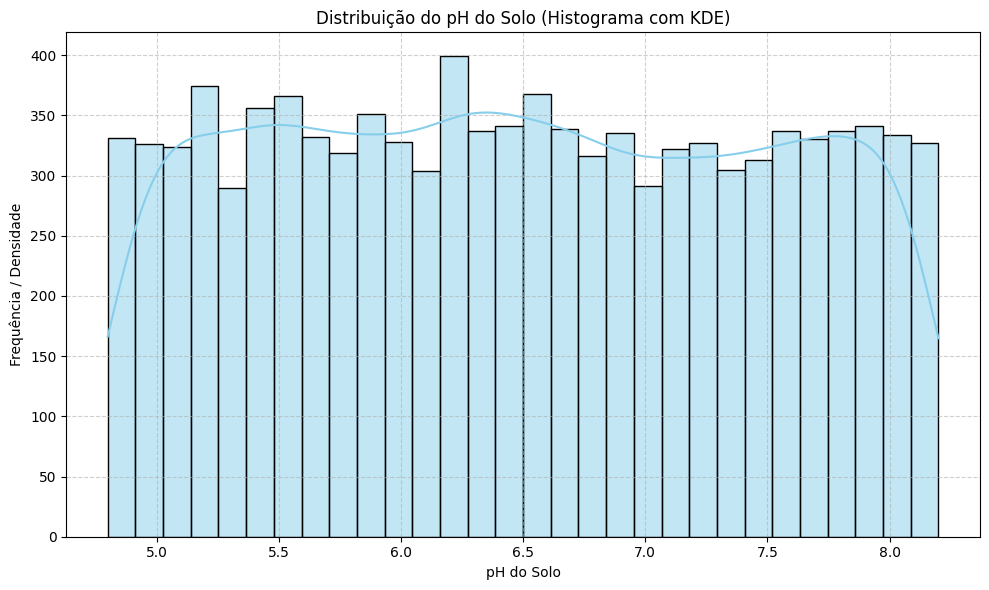

In [17]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Soil_pH'], kde=True, color='skyblue', bins=30)
plt.title('Distribuição do pH do Solo (Histograma com KDE)')
plt.xlabel('pH do Solo')
plt.ylabel('Frequência / Densidade')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Este histograma com uma linha de densidade de kernel (KDE) sobreposta mostra a distribuição da frequência do pH do solo, enquanto a linha suave do KDE estima a densidade de probabilidade. Ele destaca as faixas de pH mais comuns e a forma geral da distribuição.

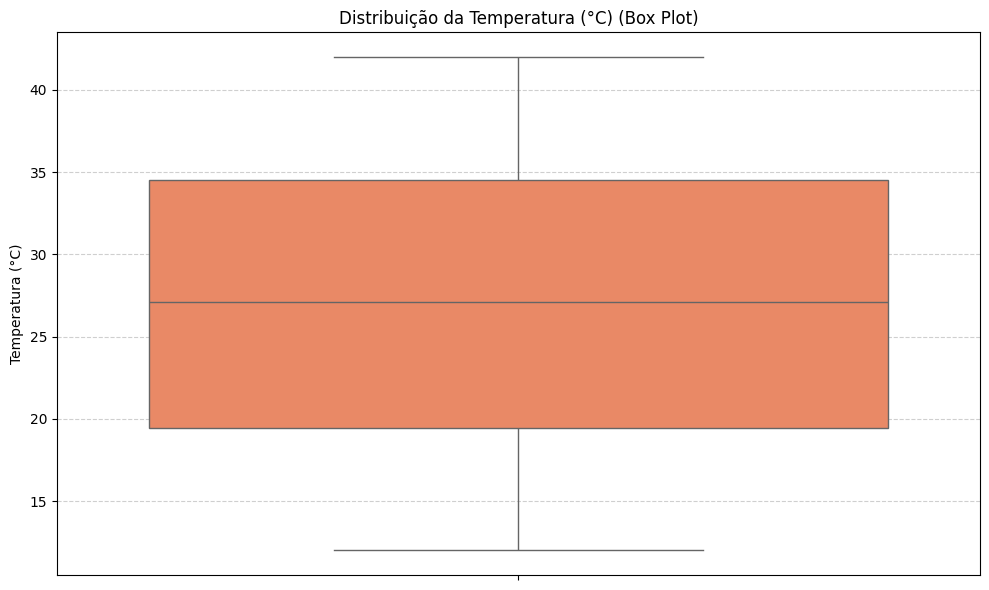

In [18]:
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['Temperature_C'], color='coral')
plt.title('Distribuição da Temperatura (°C) (Box Plot)')
plt.xlabel('')
plt.ylabel('Temperatura (°C)')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Este box plot exibe a distribuição da temperatura em Celsius. Ele mostra a mediana, os quartis (25º e 75º percentis) e a presença de possíveis *outliers*, fornecendo uma visão rápida da dispersão e tendência central dos dados de temperatura.

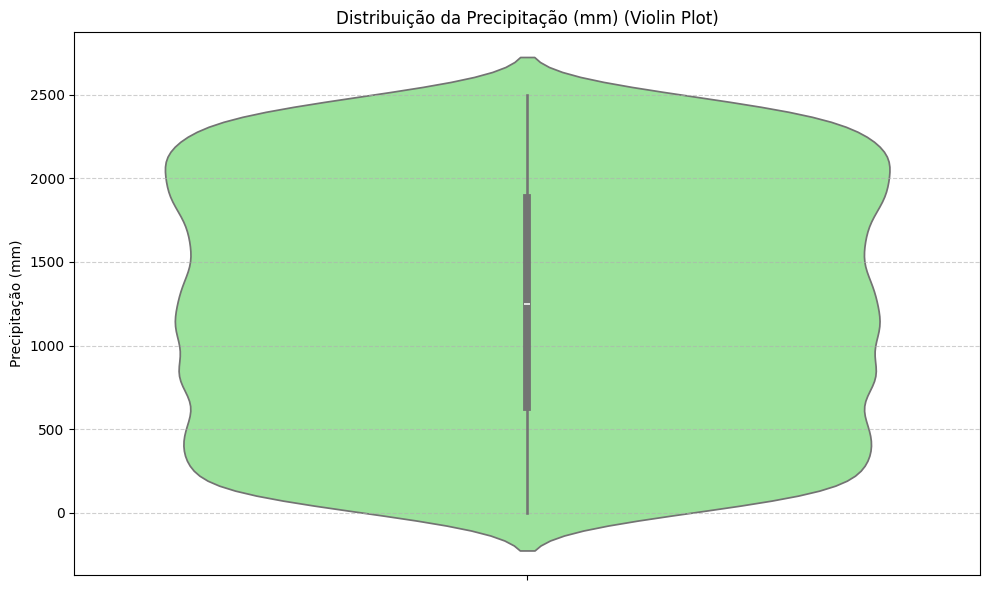

In [19]:
plt.figure(figsize=(10, 6))
sns.violinplot(y=df['Rainfall_mm'], color='lightgreen')
plt.title('Distribuição da Precipitação (mm) (Violin Plot)')
plt.xlabel('')
plt.ylabel('Precipitação (mm)')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

O violin plot para precipitação combina um box plot com um KDE, revelando a forma da distribuição dos volumes de chuva. Ele ilustra a densidade dos dados em diferentes valores, mostrando onde a precipitação é mais concentrada e sua dispersão.

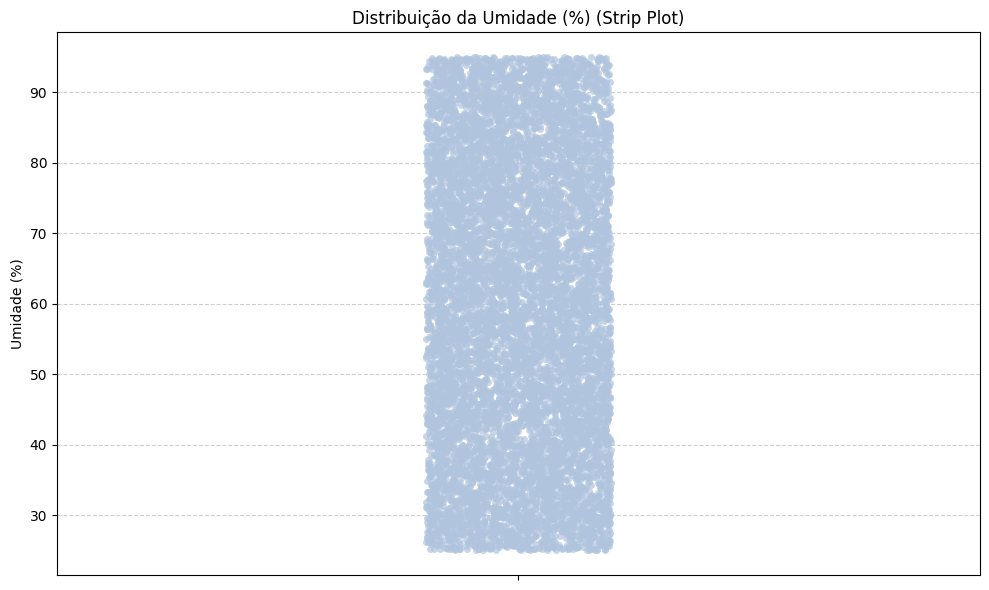

In [20]:
plt.figure(figsize=(10, 6))
sns.stripplot(y=df['Humidity'], jitter=True, color='lightsteelblue', alpha=0.7)
plt.title('Distribuição da Umidade (%) (Strip Plot)')
plt.xlabel('')
plt.ylabel('Umidade (%)')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Este strip plot mostra cada ponto de dado individual da umidade, o que é útil para visualizar a densidade e a distribuição real dos valores. O 'jitter' adicionado ajuda a evitar sobreposição, tornando todos os pontos visíveis.

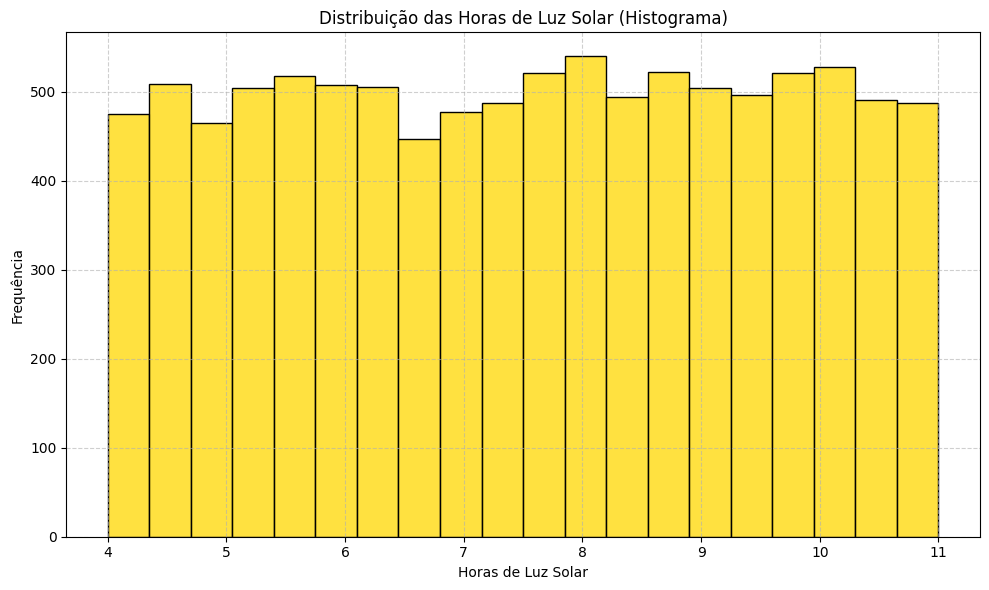

In [21]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Sunlight_Hours'], color='gold', bins=20)
plt.title('Distribuição das Horas de Luz Solar (Histograma)')
plt.xlabel('Horas de Luz Solar')
plt.ylabel('Frequência')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

O histograma das horas de luz solar apresenta a frequência com que diferentes durações de insolação ocorrem, fornecendo uma visão clara dos padrões e das faixas mais comuns de luz solar.

### Relação entre Variáveis Categóricas e Necessidade de Irrigação

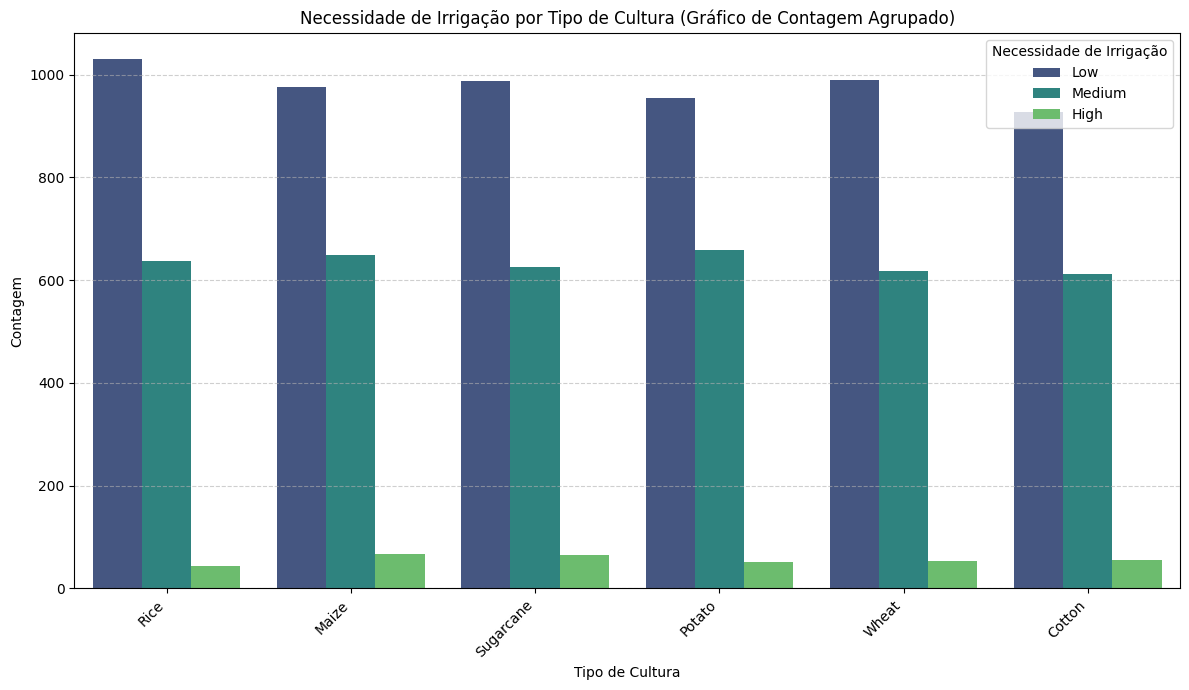

In [22]:
plt.figure(figsize=(12, 7))
sns.countplot(x='Crop_Type', hue='Irrigation_Need', data=df, order=df['Crop_Type'].value_counts().index, hue_order=irrigation_order, palette='viridis')
plt.title('Necessidade de Irrigação por Tipo de Cultura (Gráfico de Contagem Agrupado)')
plt.xlabel('Tipo de Cultura')
plt.ylabel('Contagem')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Necessidade de Irrigação')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Este gráfico de contagem agrupado exibe a frequência absoluta de cada nível de Necessidade de Irrigação (Baixa, Média, Alta) para cada Tipo de Cultura. Ele permite comparar diretamente a quantidade de ocorrências de cada necessidade entre as diferentes culturas.

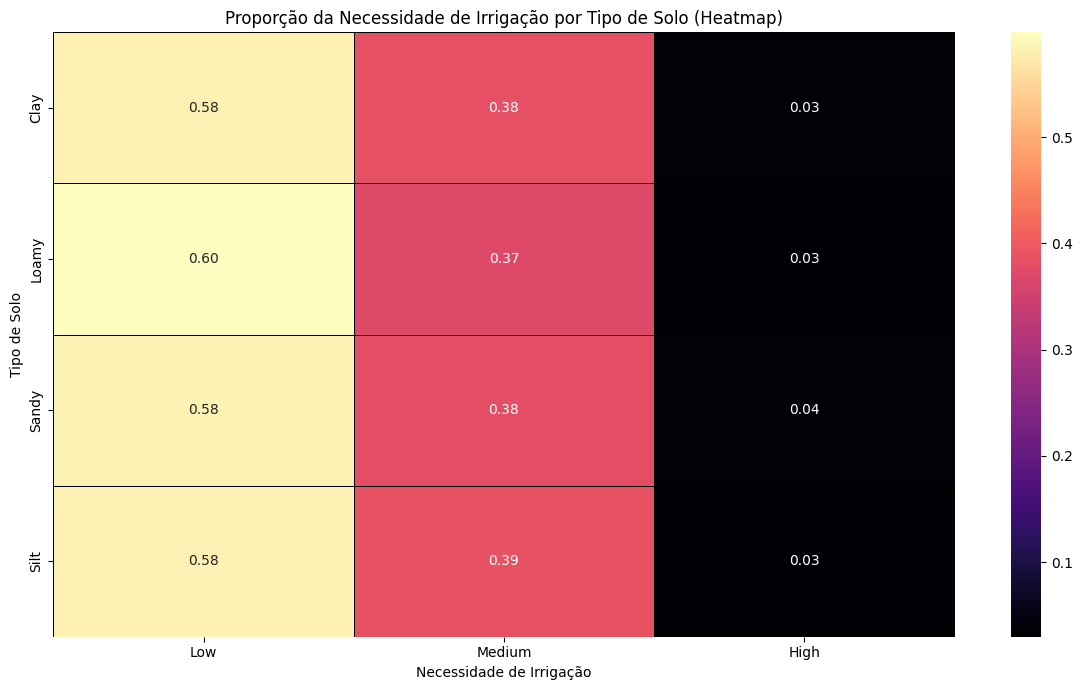

In [23]:
plt.figure(figsize=(12, 7))
soil_proportions_heatmap = pd.crosstab(df['Soil_Type'], df['Irrigation_Need'], normalize='index').loc[:, irrigation_order]
sns.heatmap(soil_proportions_heatmap, annot=True, cmap='magma', fmt='.2f', linewidths=.5, linecolor='black')
plt.title('Proporção da Necessidade de Irrigação por Tipo de Solo (Heatmap)')
plt.xlabel('Necessidade de Irrigação')
plt.ylabel('Tipo de Solo')
plt.tight_layout()
plt.show()

Este heatmap visualiza a proporção da Necessidade de Irrigação para cada Tipo de Solo. A intensidade da cor e os valores anotados indicam quais solos estão mais associados a uma maior ou menor demanda hídrica relativa, facilitando a identificação de padrões.

C:\Users\igorp\AppData\Local\Temp\ipykernel_17344\1660859871.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(x='Irrigation_Need', col='Season', data=df, kind='count', col_wrap=3, order=irrigation_order, palette='plasma', height=4, aspect=1.2)


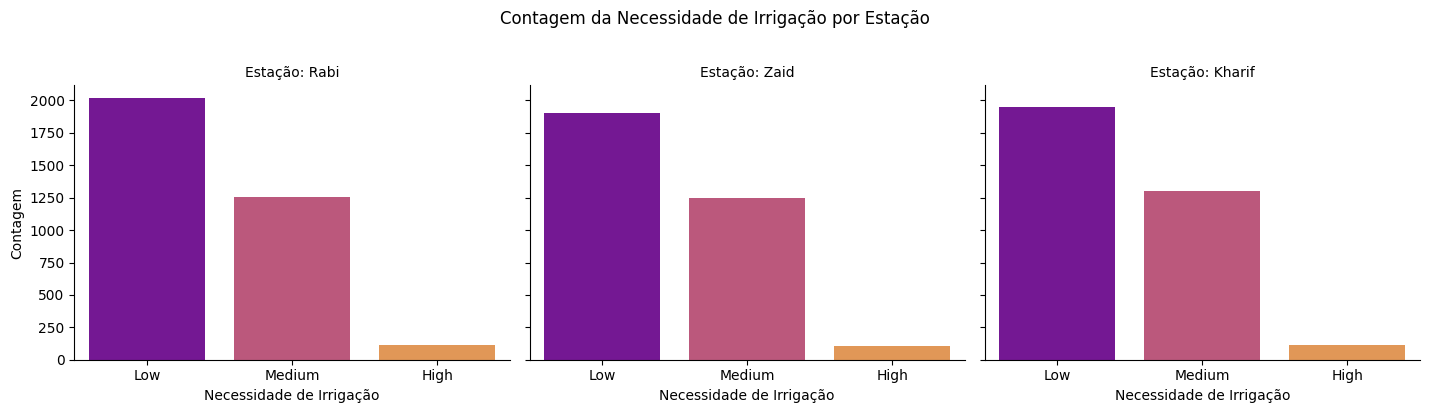

In [24]:
g = sns.catplot(x='Irrigation_Need', col='Season', data=df, kind='count', col_wrap=3, order=irrigation_order, palette='plasma', height=4, aspect=1.2)
g.set_axis_labels('Necessidade de Irrigação', 'Contagem')
g.set_titles('Estação: {col_name}')
plt.suptitle('Contagem da Necessidade de Irrigação por Estação', y=1.02)
plt.tight_layout()
plt.show()

Utilizando um FacetGrid com gráficos de contagem, esta visualização mostra a distribuição da Necessidade de Irrigação para cada estação separadamente. Isso permite uma análise detalhada de como a demanda por água se manifesta em diferentes períodos sazonais.

C:\Users\igorp\AppData\Local\Temp\ipykernel_17344\2950098994.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.pointplot(x='Irrigation_Type', y='Irrigation_Need_Numeric', data=df_temp, palette='cividis', order=df['Irrigation_Type'].value_counts().index, errorbar=('ci', 95))


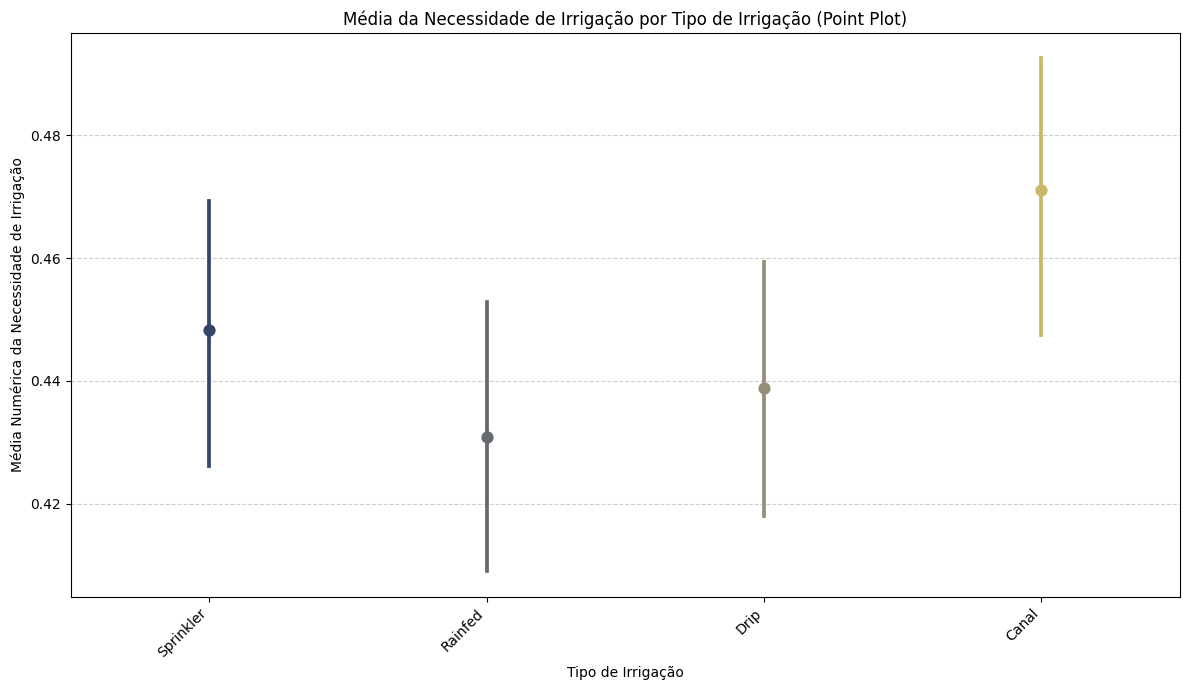

In [25]:
df_temp = df.copy()
df_temp['Irrigation_Need_Numeric'] = df_temp['Irrigation_Need'].map(irrigation_mapping)

plt.figure(figsize=(12, 7))
sns.pointplot(x='Irrigation_Type', y='Irrigation_Need_Numeric', data=df_temp, palette='cividis', order=df['Irrigation_Type'].value_counts().index, errorbar=('ci', 95))
plt.title('Média da Necessidade de Irrigação por Tipo de Irrigação (Point Plot)')
plt.xlabel('Tipo de Irrigação')
plt.ylabel('Média Numérica da Necessidade de Irrigação')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Este point plot mostra a média numérica da Necessidade de Irrigação para cada Tipo de Irrigação, com barras de erro indicando o intervalo de confiança. Isso ajuda a visualizar a tendência central e a variabilidade da demanda por água em relação aos métodos de irrigação.

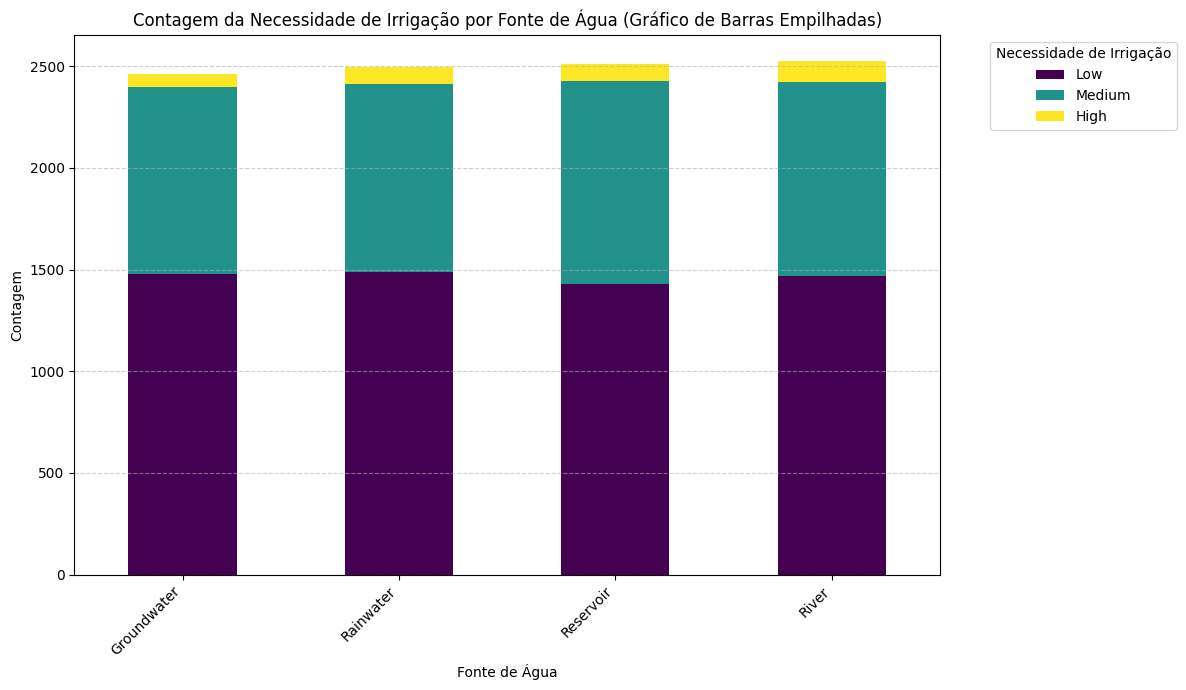

In [26]:
plt.figure(figsize=(12, 7))
water_source_counts = pd.crosstab(df['Water_Source'], df['Irrigation_Need']).loc[:, irrigation_order]
water_source_counts.plot(kind='bar', stacked=True, colormap='viridis', ax=plt.gca())
plt.title('Contagem da Necessidade de Irrigação por Fonte de Água (Gráfico de Barras Empilhadas)')
plt.xlabel('Fonte de Água')
plt.ylabel('Contagem')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Necessidade de Irrigação', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Este gráfico de barras empilhadas mostra a contagem absoluta de cada nível de Necessidade de Irrigação para cada Fonte de Água. Ele permite visualizar a contribuição de cada fonte para os diferentes níveis de demanda por água, de forma cumulativa.

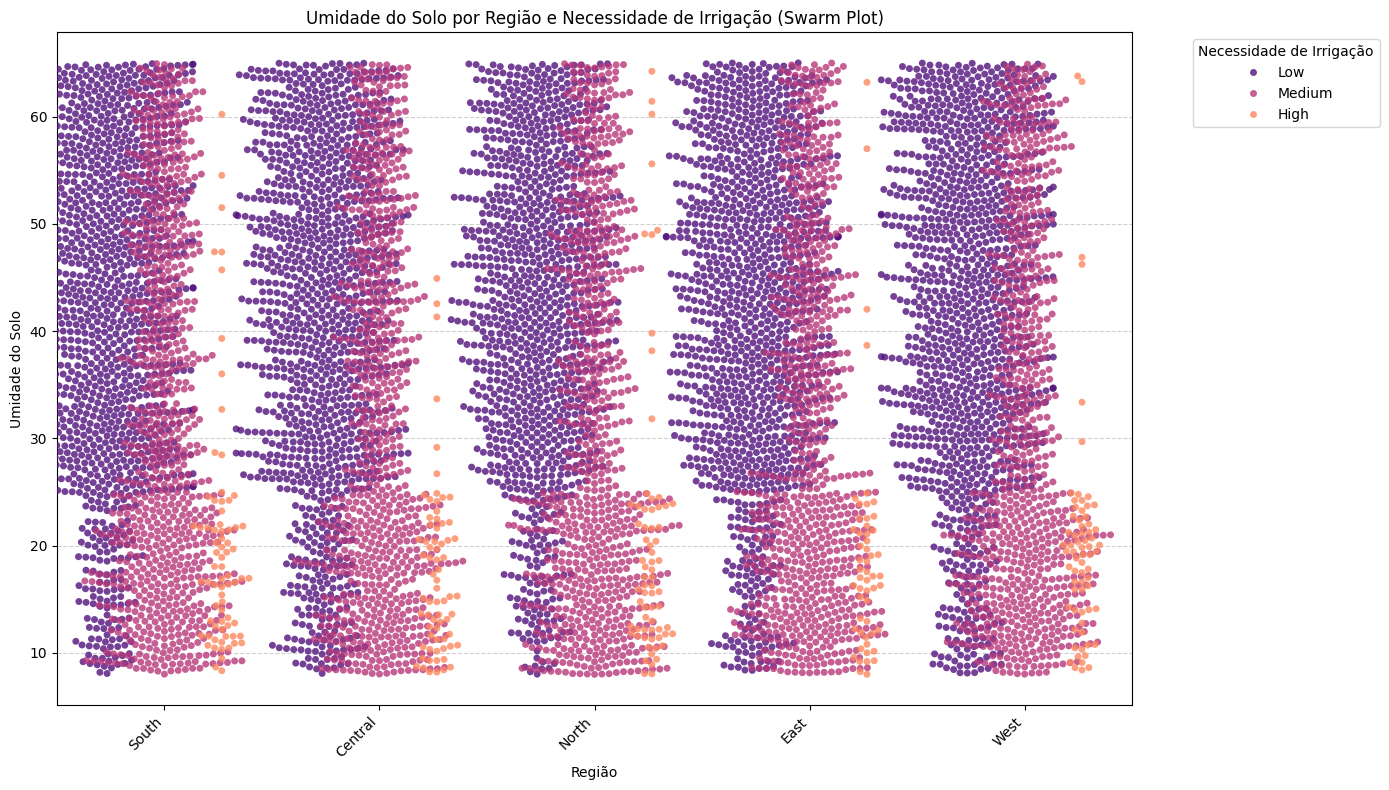

In [27]:
plt.figure(figsize=(14, 8))
sns.swarmplot(x='Region', y='Soil_Moisture', hue='Irrigation_Need', data=df, dodge=True, hue_order=irrigation_order, palette='magma', s=5, alpha=0.8)
plt.title('Umidade do Solo por Região e Necessidade de Irrigação (Swarm Plot)')
plt.xlabel('Região')
plt.ylabel('Umidade do Solo')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Necessidade de Irrigação', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Este swarm plot mostra a distribuição individual dos valores de Umidade do Solo para cada Região, com pontos coloridos pela Necessidade de Irrigação. Ele permite visualizar a densidade de pontos e como a umidade do solo varia entre as regiões e em relação à demanda hídrica.

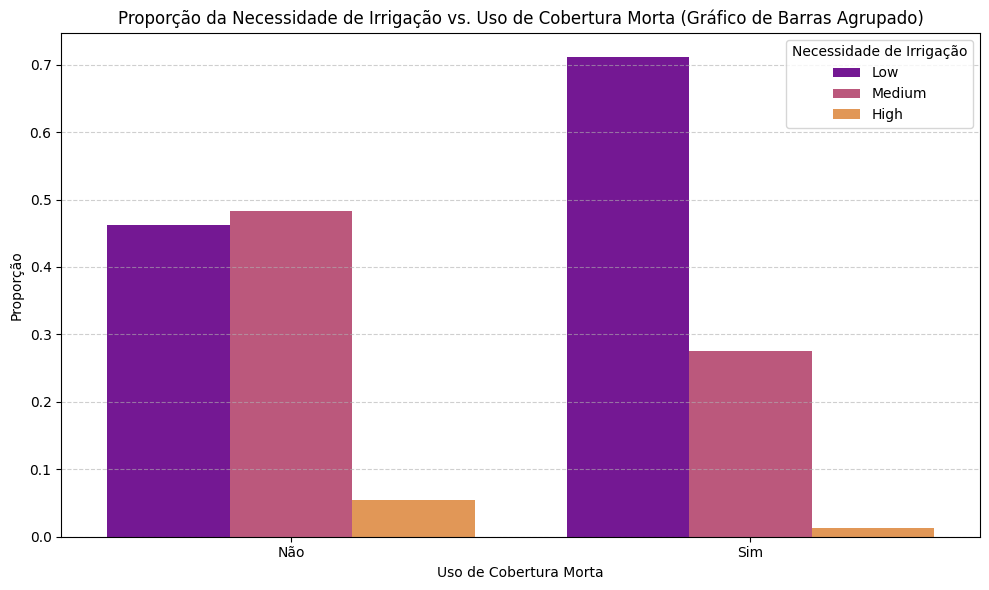

In [28]:
mulching_proportions_df = df.groupby('Mulching_Used')['Irrigation_Need'].value_counts(normalize=True).unstack().loc[:, irrigation_order]
mulching_proportions_melted = mulching_proportions_df.reset_index().melt(id_vars='Mulching_Used', var_name='Irrigation_Need', value_name='Proportion')

plt.figure(figsize=(10, 6))
sns.barplot(x='Mulching_Used', y='Proportion', hue='Irrigation_Need', data=mulching_proportions_melted, hue_order=irrigation_order, palette='plasma')
plt.title('Proporção da Necessidade de Irrigação vs. Uso de Cobertura Morta (Gráfico de Barras Agrupado)')
plt.xlabel('Uso de Cobertura Morta')
plt.ylabel('Proporção')
plt.xticks(ticks=[0, 1], labels=['Não', 'Sim'], rotation=0)
plt.legend(title='Necessidade de Irrigação')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Este gráfico de barras agrupado exibe a proporção de cada nível de Necessidade de Irrigação para o 'Uso de Cobertura Morta' (Sim ou Não). Ele destaca o impacto do mulching na distribuição da demanda por água, mostrando se essa prática está associada a uma menor proporção de alta necessidade de irrigação.

#Treinamento


### Preparação dos Dados para Treinamento

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Separar features (X) e target (y)
X = df.drop(['Irrigation_Need', 'Water_Source', 'Region', 'Electrical_Conductivity', 'Organic_Carbon', 'Soil_pH'], axis=1)
y = df['Irrigation_Need']

# Identificar colunas categóricas e numéricas
categorical_features = X.select_dtypes(include=['object']).columns
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns

# Pré-processamento para dados numéricos (escalar) e categóricos (one-hot encode)
numerical_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Dividir os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Dados preparados para treinamento.")
print(f"Tamanho do conjunto de treino: {X_train.shape[0]} amostras")
print(f"Tamanho do conjunto de teste: {X_test.shape[0]} amostras")

Dados preparados para treinamento.
Tamanho do conjunto de treino: 8000 amostras
Tamanho do conjunto de teste: 2000 amostras


### Treinamento e Avaliação dos Modelos

Vamos treinar e avaliar três modelos de classificação diferentes: Regressão Logística, Random Forest e Gradient Boosting.

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, accuracy_score
import joblib

models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

results = {}

best_model = None
best_accuracy = 0

for name, model in models.items():
    print(f"\nTreinando {name}...")
    pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('classifier', model)])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)

    results[name] = {
        'accuracy': accuracy,
        'report': report,
        'model': pipeline
    }

    print(f"{name} - Acurácia: {accuracy:.4f}")
    print(f"Relatório de Classificação para {name}:\n{report}")

    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_model = pipeline
        best_model_name = name

print(f"\nO melhor modelo é: {best_model_name} com acurácia de {best_accuracy:.4f}")

# Salvar o melhor modelo usando joblib
joblib.dump(best_model, 'best_irrigation_model.joblib')
print(f"Modelo '{best_model_name}' salvo como 'best_irrigation_model.joblib'")


Treinando Logistic Regression...
Logistic Regression - Acurácia: 0.8240
Relatório de Classificação para Logistic Regression:
              precision    recall  f1-score   support

        High       0.73      0.40      0.52        67
         Low       0.87      0.88      0.87      1173
      Medium       0.76      0.78      0.77       760

    accuracy                           0.82      2000
   macro avg       0.79      0.69      0.72      2000
weighted avg       0.82      0.82      0.82      2000


Treinando Random Forest...
Random Forest - Acurácia: 0.9810
Relatório de Classificação para Random Forest:
              precision    recall  f1-score   support

        High       1.00      0.60      0.75        67
         Low       0.99      1.00      1.00      1173
      Medium       0.97      0.99      0.98       760

    accuracy                           0.98      2000
   macro avg       0.99      0.86      0.91      2000
weighted avg       0.98      0.98      0.98      2000


Tre

### Teste do Modelo

In [32]:
import joblib

# Carregar o melhor modelo salvo
loaded_model = joblib.load('best_irrigation_model.joblib')

print("Modelo carregado com sucesso!")

Modelo carregado com sucesso!


In [33]:
import numpy as np

# Criar um novo ponto de dados para teste (exemplo)
# Usaremos o primeiro registro do X_test como exemplo, mas sem a coluna 'Irrigation_Need'
# Certifique-se de que a ordem e os tipos das colunas correspondam aos dados de treinamento.

sample_data = X_test.iloc[[0]].copy()

print("Dados de exemplo para previsão:")
display(sample_data)

Dados de exemplo para previsão:


,Soil_Type,Soil_Moisture,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm
4049,Silt,26.1,18.11,43.18,1416.9,9.44,12.15,Sugarcane,Flowering,Zaid,Sprinkler,7.25,0,51.55


In [34]:
# Realizar a previsão
prediction = loaded_model.predict(sample_data)

print(f"A previsão da Necessidade de Irrigação para o dado de exemplo é: {prediction[0]}")

A previsão da Necessidade de Irrigação para o dado de exemplo é: Medium


Este teste demonstra como carregar o modelo salvo e usá-lo para fazer previsões em novos dados. A previsão para o primeiro dado de teste foi calculada e exibida.